# CMT — large300 — Nouveaux objectifs de stage

1. **Visualisation** à un temps donné (+ évolution) : flux de Reynolds, cisaillement, $u$, $w$, $\partial_z u$, $\partial_z^2 u$.
2. **Equation discovery (STLSQ)** avec des termes physiques *grande échelle* uniquement.
3. **Robustesse temporelle** du split train/test (walk-forward vs split aléatoire).
4. **$\psi$ moyennée en $y$ → POD** : combien de modes garder, reconstruction de $u,w$.
5. **Circulation** — cellules fermées de $\psi$ à signe unique.

Setup identique à d'habitude : lecture niveau par niveau, $\rho_0$ via $T_v$, masques PRW, pas de dépendance nouvelle (numpy / scipy / xarray / matplotlib seulement).


## 0. Imports & configuration

Identique au pipeline **large300** habituel : fichiers 3D séparés par variable dans `3D/MESONH_RCE_large300_3D_{var}.nc` (variables `ua`,`va`,`wa`,`ta`,`pa`,`hus`), altitude reprise du 1D, état stationnaire = **dernier tiers** des pas de temps, $\rho_0(z)$ via la température virtuelle. Lecture **niveau par niveau** pour la RAM.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.optimize import curve_fit
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve
from scipy.ndimage import label as ndi_label

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.25,
    'image.cmap': 'RdBu_r',
})

# ============================================================
#  CONFIGURATION  (identique au notebook rcemip_large300)
# ============================================================
DIR_3D = '3D';  DIR_2D = '2D';  DIR_1D = '1D'
def path3d(var): return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{var}.nc')
def path2d(var): return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{var}.nc')
def path1d(var): return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{var}.nc')

Rd, Rv = 287.05, 461.5
EPSILON = Rd / Rv          # ~ 0.622
BLOC    = 2                # taille de bloc temporel (RAM)

print('Config prête.')


Config prête.


In [2]:

# --- (0a) Métadonnées : dims, tailles, altitude, fenêtre stationnaire ---
_ds = xr.open_dataset(path3d('ua'));  _da = _ds['ua']
dim_t, dim_z, dim_y, dim_x = _da.dims        # ordre (t, z, y, x)
n_t = _da.sizes[dim_t];  n_z = _da.sizes[dim_z]
n_y = _da.sizes[dim_y];  n_x = _da.sizes[dim_x]
_ds.close();  del _ds, _da;  gc.collect()

_t1 = xr.open_dataset(path1d('ua_avg'))
alt = _t1['altitude'].values.astype(float).copy()
_t1.close()

t_stat   = int(2 * n_t / 3)          # dernier tiers = stationnaire
idx_stat = slice(t_stat, None)
n_stat   = n_t - t_stat
print(f'Grille : {n_t} t x {n_z} z x {n_y} y x {n_x} x')
print(f'Altitude : {alt[0]:.0f} -> {alt[-1]:.0f} m')
print(f'Stationnaire : t={t_stat}->{n_t-1} ({n_stat} pas)')

# grille horizontale (m) — dx/dy = 1000 m par défaut si coords = indices
try:
    xcoord = _ds.coords[dim_x].values.astype(float)
    dx = float(xcoord[1] - xcoord[0])
    if dx < 10:  # coords = indices entiers -> fallback
        raise ValueError
except Exception:
    dx = 1000.0
dy = dx
x = np.arange(n_x) * dx
print(f'dx = dy = {dx:.0f} m')


Grille : 100 t x 74 z x 128 y x 2000 x
Altitude : 0 -> 32500 m
Stationnaire : t=66->99 (34 pas)
dx = dy = 1000 m


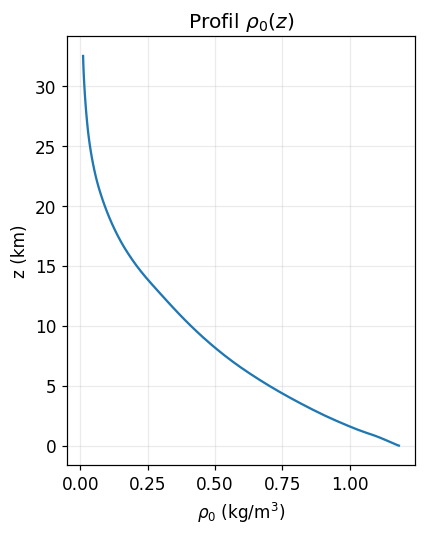

In [3]:

# --- (0b) Profil rho_0(z) via température virtuelle (gaz parfaits) ---
rho0 = np.zeros(n_z)
ds_ta  = xr.open_dataset(path3d('ta'))
ds_pa  = xr.open_dataset(path3d('pa'))
ds_hus = xr.open_dataset(path3d('hus'))
for iz in range(n_z):
    ta_z  = ds_ta['ta'].isel({dim_z: iz, dim_t: idx_stat}).values
    pa_z  = ds_pa['pa'].isel({dim_z: iz, dim_t: idx_stat}).values
    hus_z = ds_hus['hus'].isel({dim_z: iz, dim_t: idx_stat}).values
    tv = ta_z * (1.0 + (1.0 / EPSILON - 1.0) * hus_z)
    rho0[iz] = np.mean(pa_z / (Rd * tv))
ds_ta.close(); ds_pa.close(); ds_hus.close(); gc.collect()

fig, ax = plt.subplots(figsize=(4, 5))
ax.plot(rho0, alt / 1000)
ax.set_xlabel(r'$\rho_0$ (kg/m$^3$)'); ax.set_ylabel('z (km)')
ax.set_title(r'Profil $\rho_0(z)$')
fig.tight_layout(); plt.show()


Seuil PRW = 28.0 kg/m2  -  50% de colonnes humides


/tmp/ipykernel_7752/1271306481.py:12: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(prw, cmap='YlGnBu', shading='auto')


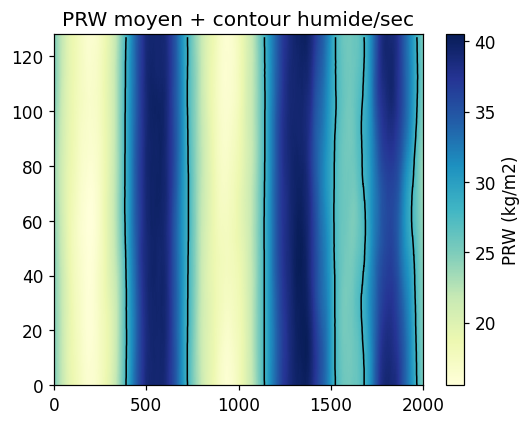

In [4]:

# --- (0c) Masques humide / sec (PRW), 2D (y,x), seuil = médiane ---
ds_prw = xr.open_dataset(path2d('prw'))
prw_t  = ds_prw['prw'].isel({dim_t: idx_stat}).values     # (n_stat, ny, nx)
ds_prw.close(); gc.collect()
prw = prw_t.mean(axis=0)                                   # moyenne temporelle (ny,nx)
seuil_prw = np.median(prw)
mh = prw > seuil_prw     # humide
ms = ~mh                 # sec
print(f'Seuil PRW = {seuil_prw:.1f} kg/m2  -  {mh.mean()*100:.0f}% de colonnes humides')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.pcolormesh(prw, cmap='YlGnBu', shading='auto')
ax.contour(mh.astype(float), levels=[0.5], colors='k', linewidths=1)
ax.set_title('PRW moyen + contour humide/sec')
fig.colorbar(im, ax=ax, label='PRW (kg/m2)')
fig.tight_layout(); plt.show()


## 1. Visualisation — champs à un temps donné + évolution temporelle

Flux de Reynolds $\rho_0\langle u'w'\rangle$, cisaillement $\partial_z\bar u$, $\bar u$, $\bar w$, $\partial_z\bar u$, $\partial_z^2\bar u$ — à un instant donné et en évolution (Hovmöller $z$-$t$).

In [5]:

# --- Profils rho0<u'w'>(z,t), ubar(z,t), wbar(z,t), niveau par niveau ---
flux  = np.zeros((n_z, n_stat))
ubar  = np.zeros((n_z, n_stat))
wbar  = np.zeros((n_z, n_stat))

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_z: iz, dim_t: idx_stat}).values   # (n_stat, ny, nx)
    w = ds_w['wa'].isel({dim_z: iz, dim_t: idx_stat}).values
    ub = u.mean(axis=(1, 2))
    wb = w.mean(axis=(1, 2))
    up = u - ub[:, None, None]
    wp = w - wb[:, None, None]
    flux[iz, :] = rho0[iz] * (up * wp).mean(axis=(1, 2))
    ubar[iz, :] = ub
    wbar[iz, :] = wb
ds_u.close(); ds_w.close(); gc.collect()

dudz   = np.gradient(ubar, alt, axis=0)
d2udz2 = np.gradient(dudz, alt, axis=0)
print('flux, ubar, wbar, dudz, d2udz2 prêts :', flux.shape)


flux, ubar, wbar, dudz, d2udz2 prêts : (74, 34)


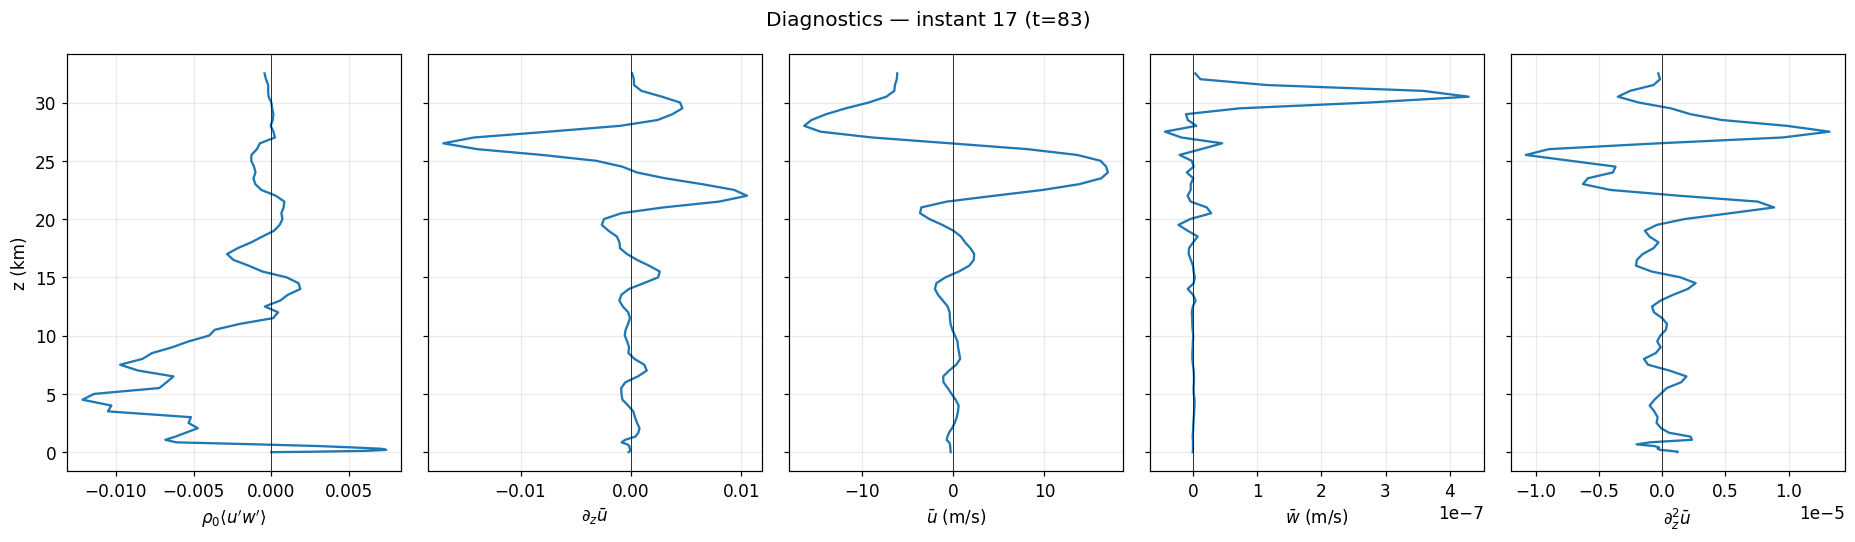

In [6]:

def dashboard_at_time(it):
    '''Panneau de profils verticaux a l instant it (indice dans la fenetre stationnaire).'''
    fig, axes = plt.subplots(1, 5, figsize=(17, 5), sharey=True)
    panels = [
        (flux[:, it],   r"$\rho_0\langle u'w'\rangle$"),
        (dudz[:, it],   r"$\partial_z \bar u$"),
        (ubar[:, it],   r"$\bar u$ (m/s)"),
        (wbar[:, it],   r"$\bar w$ (m/s)"),
        (d2udz2[:, it], r"$\partial_z^2 \bar u$"),
    ]
    for ax, (field, label) in zip(axes, panels):
        ax.plot(field, alt / 1000, lw=1.5)
        ax.axvline(0, color='k', lw=0.5)
        ax.set_xlabel(label)
    axes[0].set_ylabel('z (km)')
    fig.suptitle(f'Diagnostics — instant {it} (t={t_stat+it})')
    fig.tight_layout()
    plt.show()

dashboard_at_time(n_stat // 2)


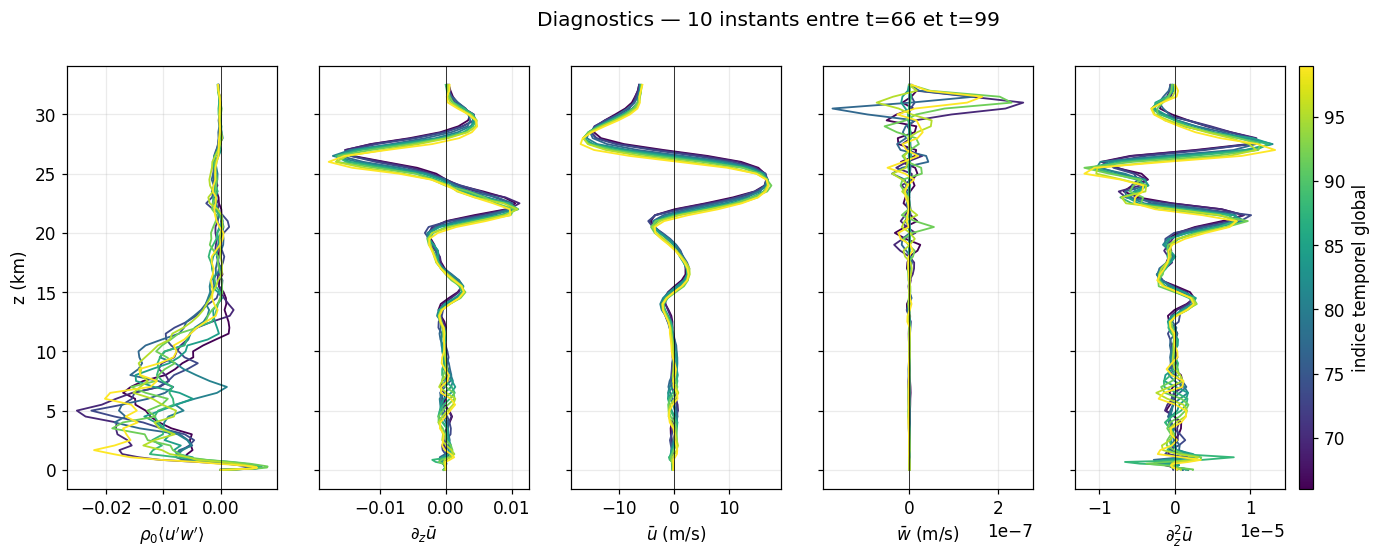

In [7]:
def dashboard_multi_time(its, cmap_name='viridis'):
    '''Panneau de profils verticaux superposant plusieurs instants (dégradé = temps).'''
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0, 1, len(its)))

    fig, axes = plt.subplots(1, 5, figsize=(17, 5), sharey=True)
    panels = [
        (flux,   r"$\rho_0\langle u'w'\rangle$"),
        (dudz,   r"$\partial_z \bar u$"),
        (ubar,   r"$\bar u$ (m/s)"),
        (wbar,   r"$\bar w$ (m/s)"),
        (d2udz2, r"$\partial_z^2 \bar u$"),
    ]
    for ax, (field, label) in zip(axes, panels):
        for it, c in zip(its, colors):
            ax.plot(field[:, it], alt / 1000, lw=1.2, color=c)
        ax.axvline(0, color='k', lw=0.5)
        ax.set_xlabel(label)
    axes[0].set_ylabel('z (km)')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=t_stat, vmax=t_stat + n_stat - 1))
    fig.colorbar(sm, ax=axes, label='indice temporel global', pad=0.01, aspect=30)
    fig.suptitle(f'Diagnostics — {len(its)} instants entre t={t_stat+its[0]} et t={t_stat+its[-1]}')
    plt.show()


its = np.linspace(0, n_stat - 1, 10, dtype=int)
dashboard_multi_time(its)

## 2. Equation discovery — termes physiques grande échelle uniquement

Bibliothèque de candidats : $\{\bar u,\ \partial_z\bar u,\ \partial_z^2\bar u,\ \bar w,\ \bar u\partial_z\bar u,\ z\partial_z\bar u,\ \bar u^2\}$ — uniquement des quantités grande échelle, pas de termes de sous-maille. STLSQ codé à la main (déjà la méthode utilisée dans le notebook `6_CMT_trois_objectifs`), pas de nouvelle dépendance.

33 niveaux entre 2055 et 18000 m (sur 74 au total)
Termes retenus :
  dudz            : -1.4625e+02
  d2udz2          : +1.4836e+04
  dudz2           : +3.2312e+02
  dudz_d2udz2     : +1.5154e+06
  u               : +3.5746e-03
  u2              : +1.8617e-03
  u_dudz          : +2.5025e+00
  u_d2udz2        : +1.3217e+03
  w2              : +1.5347e+13
  w_d2udz2        : -1.9322e+10
  rho0_dudz       : +9.6381e+01
  rho0_d2udz2     : -1.8179e+04
  drho0dz_u       : +1.2404e+02
  drho0dz_dudz    : -3.7148e+05
  z_dudz          : +2.7542e-03
  z_d2udz2        : -7.0345e-01
  zHz_dudz        : +2.8096e-07
  zHz             : +3.4810e-02
  intercept       : -1.5847e-02

NSE (2-18 km, z-t complet) = 0.617


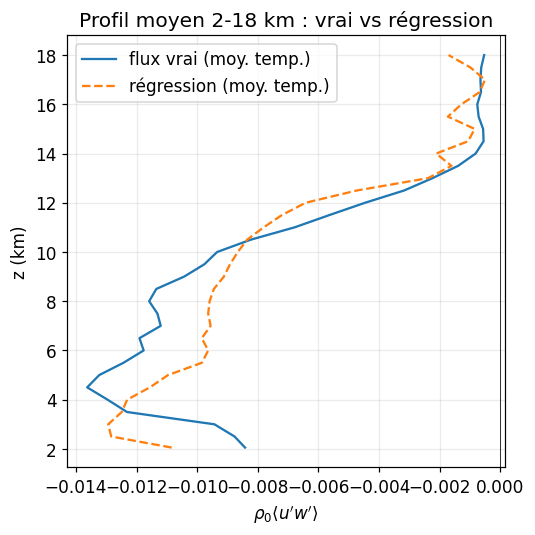

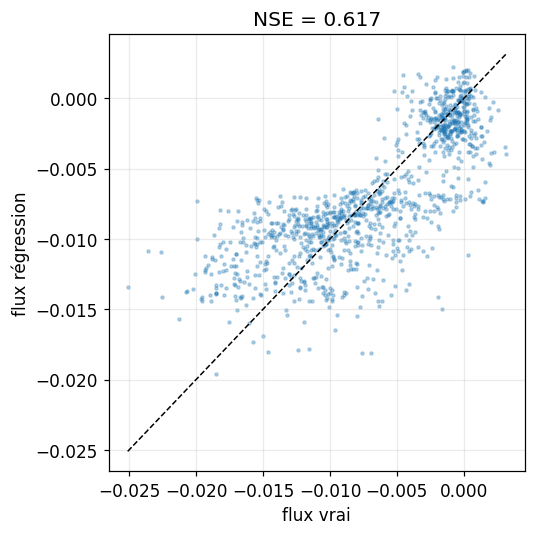

In [8]:
# ============================================================
# OBJECTIF 2 — Equation discovery, restreint à 2-18 km
# ============================================================

# --- restriction verticale, appliquée aux grandeurs déjà calculées sur la
#     grille complète (dudz/d2udz2 restent dérivés sur toute la colonne,
#     puis on tronque — ça évite les artefacts de bord d'une dérivation
#     faite directement sur la fenêtre réduite) ---
mask_z = (alt >= 2000) & (alt <= 18000)
alt_r, rho0_r, ubar_r, wbar_r, dudz_r, d2udz2_r, flux_r = (
    a[mask_z] for a in (alt, rho0, ubar, wbar, dudz, d2udz2, flux)
)
n_z_r = alt_r.size
print(f'{n_z_r} niveaux entre {alt_r[0]:.0f} et {alt_r[-1]:.0f} m (sur {n_z} au total)')

d3udz3_r  = np.gradient(d2udz2, alt, axis=0)[mask_z]
dwdz_r    = np.gradient(wbar, alt, axis=0)[mask_z]
drho0dz_r = np.gradient(rho0, alt)[mask_z][:, None]


def build_library():
    '''Bibliothèque grande échelle, restreinte à 2-18 km.'''
    Z = np.tile(alt_r[:, None], (1, n_stat))
    H = alt.max()                          # sommet convectif = pleine colonne (référence physique)
    rho0_2d = np.tile(rho0_r[:, None], (1, n_stat))

    terms = {
        'dudz':         dudz_r,
        'd2udz2':       d2udz2_r,
        'd3udz3':       d3udz3_r,
        'dudz2':        dudz_r ** 2,
        'absdudz_dudz': np.abs(dudz_r) * dudz_r,
        'dudz_d2udz2':  dudz_r * d2udz2_r,
        'd2udz2_2':     d2udz2_r ** 2,
        'u':        ubar_r,
        'u2':       ubar_r ** 2,
        'u3':       ubar_r ** 3,
        'u_dudz':   ubar_r * dudz_r,
        'u_d2udz2': ubar_r * d2udz2_r,
        'u2_dudz':  ubar_r ** 2 * dudz_r,
        'w':        wbar_r,
        'w2':       wbar_r ** 2,
        'w_dudz':   wbar_r * dudz_r,
        'w_d2udz2': wbar_r * d2udz2_r,
        'dwdz':     dwdz_r,
        'w_u':      wbar_r * ubar_r,
        'rho0_dudz':    rho0_2d * dudz_r,
        'rho0_d2udz2':  rho0_2d * d2udz2_r,
        'drho0dz_u':    drho0dz_r * ubar_r,
        'drho0dz_dudz': drho0dz_r * dudz_r,
        'z_dudz':   Z * dudz_r,
        'z2_dudz':  Z ** 2 * dudz_r,
        'z_d2udz2': Z * d2udz2_r,
        'zHz_dudz': Z * (H - Z) * dudz_r,
        'zHz':      (Z / H) * (1 - Z / H),
    }
    names = list(terms.keys())
    Theta = np.stack([terms[n].ravel() for n in names], axis=1)
    return Theta, names


def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot


def stlsq(Theta, y, threshold=0.05, n_iter=15, alpha=1e-8):
    n_terms = Theta.shape[1]
    coef = np.linalg.solve(Theta.T @ Theta + alpha * np.eye(n_terms), Theta.T @ y)
    active = np.ones(n_terms, dtype=bool)
    for _ in range(n_iter):
        small = np.abs(coef) < threshold
        if not np.any(small & active):
            break
        active[small] = False
        if not np.any(active):
            break
        Xs = Theta[:, active]
        coef_active = np.linalg.solve(Xs.T @ Xs + alpha * np.eye(Xs.shape[1]), Xs.T @ y)
        coef = np.zeros(n_terms)
        coef[active] = coef_active
    return coef, active


# --- fit ---
Theta, names = build_library()
y = flux_r.ravel()

mu, sigma = Theta.mean(axis=0), Theta.std(axis=0) + 1e-12
Theta_n = (Theta - mu) / sigma
y_n = (y - y.mean()) / (y.std() + 1e-12)

coef_n, active = stlsq(Theta_n, y_n, threshold=0.08)
coef = coef_n * (y.std() / sigma)
intercept = y.mean() - mu @ coef

print('Termes retenus :')
for name, c, a in zip(names, coef, active):
    if a:
        print(f'  {name:15s} : {c:+.4e}')
print(f'  intercept       : {intercept:+.4e}')

flux_pred = (Theta @ coef + intercept).reshape(n_z_r, n_stat)
r2 = nse(flux_r, flux_pred)
print(f'\nNSE (2-18 km, z-t complet) = {r2:.3f}')


fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(flux_r.mean(axis=1), alt_r / 1000, label='flux vrai (moy. temp.)')
ax.plot(flux_pred.mean(axis=1), alt_r / 1000, '--', label='régression (moy. temp.)')
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r"$\rho_0\langle u'w'\rangle$"); ax.set_ylabel('z (km)')
ax.legend(); ax.set_title('Profil moyen 2-18 km : vrai vs régression')
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(flux_r.ravel(), flux_pred.ravel(), s=4, alpha=0.3)
lims = [min(flux_r.min(), flux_pred.min()), max(flux_r.max(), flux_pred.max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('flux vrai'); ax.set_ylabel('flux régression')
ax.set_title(f'NSE = {r2:.3f}')
fig.tight_layout(); plt.show()

Contribution relative (%) au profil moyen 2-18 km :
  dudz            :  37.6%
  zHz_dudz        :  17.6%
  z_dudz          :   9.8%
  intercept       :   7.6%
  rho0_dudz       :   6.9%
  d2udz2          :   4.1%
  drho0dz_dudz    :   3.6%
  zHz             :   3.2%
  z_d2udz2        :   2.6%
  rho0_d2udz2     :   1.4%
  drho0dz_u       :   1.4%
  u               :   1.2%
  u2              :   1.1%
  u_dudz          :   0.7%
  u_d2udz2        :   0.7%
  dudz_d2udz2     :   0.4%
  dudz2           :   0.1%
  w2              :   0.0%
  w_d2udz2        :   0.0%


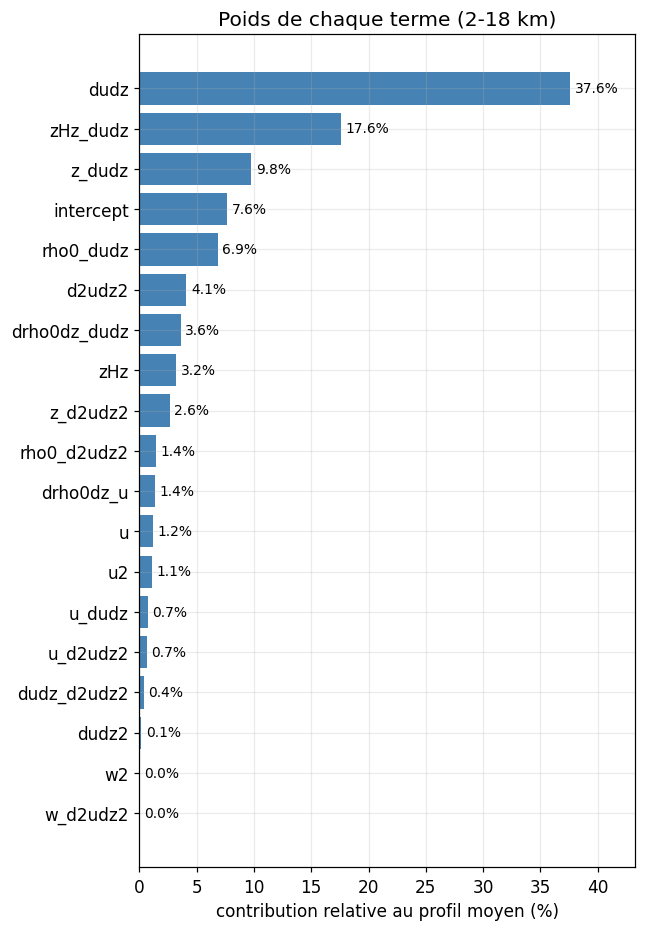

In [9]:
# ============================================================
# Contribution en pourcentage de chaque terme retenu
# ============================================================

importance = {}
for j, (name, c, a) in enumerate(zip(names, coef, active)):
    if not a:
        continue
    contrib = (Theta[:, j] * c).reshape(n_z_r, n_stat).mean(axis=1)   # profil moyen dans le temps
    importance[name] = np.sum(np.abs(contrib))                        # poids intégré sur 2-18 km

importance['intercept'] = np.sum(np.abs(np.full(n_z_r, intercept)))

total = sum(importance.values())
pct = {name: 100 * v / total for name, v in importance.items()}
pct_sorted = dict(sorted(pct.items(), key=lambda kv: kv[1], reverse=True))

print('Contribution relative (%) au profil moyen 2-18 km :')
for name, p in pct_sorted.items():
    print(f'  {name:15s} : {p:5.1f}%')

fig, ax = plt.subplots(figsize=(6, 0.4 * len(pct_sorted) + 1))
bars = ax.barh(list(pct_sorted.keys())[::-1], list(pct_sorted.values())[::-1], color='steelblue')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('contribution relative au profil moyen (%)')
ax.set_title('Poids de chaque terme (2-18 km)')
ax.set_xlim(0, max(pct_sorted.values()) * 1.15)
fig.tight_layout(); plt.show()

## 4. $\psi$ moyennée en $y$ → POD

On calcule $\psi(x,z,t)$ (moyenne-$y$) via le solveur de Poisson périodique-$x$/Dirichlet-$z$ déjà utilisé (notebook lignes de courant), puis une POD par **méthode des snapshots** (`Amat @ Amat.T`, `eigh`) — exactement la méthode déjà validée sur `6_CMT_trois_objectifs`, pas de sklearn.

$$\psi(x,z,t) \approx \bar\psi(x,z) + \sum_n a_n(t)\,\psi_n(x,z), \qquad \tilde u_N=\partial_z\tilde\psi_N/\rho_0,\ \ \tilde w_N=-\partial_x\tilde\psi_N/\rho_0$$

In [10]:

def psi_poisson_periodic(U2d, W2d, xv, zv, rho0v):
    '''nabla^2 psi = d_x(rho0 w) - d_z(rho0 u), periodique en x, Dirichlet en z.'''
    nz, nx = U2d.shape
    dxl = xv[1] - xv[0]
    rW = rho0v[:, None] * W2d
    rU = rho0v[:, None] * U2d
    dxrW = (np.roll(rW, -1, axis=1) - np.roll(rW, 1, axis=1)) / (2 * dxl)
    dzrU = np.gradient(rU, zv, axis=0)
    omega = dxrW - dzrU

    main_x = -2 * np.ones(nx); off_x = np.ones(nx - 1)
    Lx = diags([main_x, off_x, off_x, [1], [1]], [0, 1, -1, nx - 1, -(nx - 1)]) / dxl ** 2
    dz_mean = np.mean(np.diff(zv))
    main_z = -2 * np.ones(nz); off_z = np.ones(nz - 1)
    Lz = diags([main_z, off_z, off_z], [0, 1, -1]) / dz_mean ** 2
    A = (kron(identity(nz), Lx) + kron(Lz, identity(nx))).tolil()
    b = omega.ravel().copy()

    psi_top = np.cumsum(rho0v * U2d.mean(axis=1)) * dz_mean
    for i in range(nx):
        k0 = i;               A.rows[k0] = [k0]; A.data[k0] = [1.0]; b[k0] = 0.0
        k1 = (nz - 1) * nx + i; A.rows[k1] = [k1]; A.data[k1] = [1.0]; b[k1] = psi_top[-1]
    psi = spsolve(A.tocsr(), b).reshape(nz, nx)
    return psi


In [11]:

# --- construction des snapshots psi(x,z,t) moyenne-y, sous-echantillonnage temporel raisonnable ---
STRIDE_T = max(1, n_stat // 60)     # ~60 instants au plus pour rester rapide
t_idx_pod = np.arange(0, n_stat, STRIDE_T)

psi_snaps = np.zeros((len(t_idx_pod), n_z, n_x))
ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))
for i_snap, it in enumerate(t_idx_pod):
    it_global = t_stat + it
    U2d = ds_u['ua'].isel({dim_t: it_global}).mean(dim=dim_y).values   # (nz, nx)
    W2d = ds_w['wa'].isel({dim_t: it_global}).mean(dim=dim_y).values
    psi_snaps[i_snap] = psi_poisson_periodic(U2d, W2d, x, alt, rho0)
ds_u.close(); ds_w.close(); gc.collect()
print('psi_snaps :', psi_snaps.shape)


psi_snaps : (34, 74, 2000)


10 modes pour 90% de l energie (sur 34 modes).


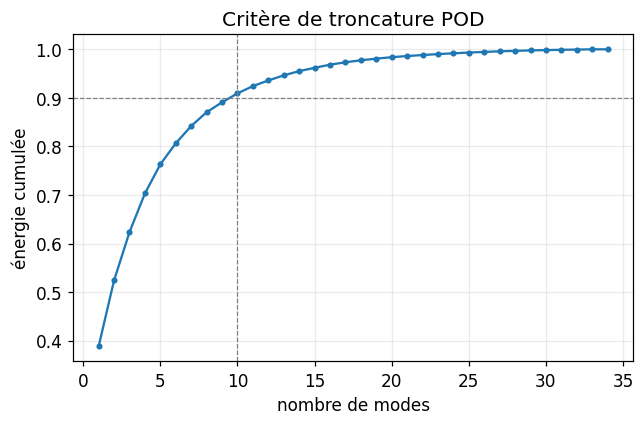

In [12]:

# --- POD methode des snapshots (centree !) ---
N = psi_snaps.shape[0]
fmean = psi_snaps.mean(axis=0)
Amat = (psi_snaps - fmean).reshape(N, -1)          # ANOMALIES centrees

Cs = Amat @ Amat.T / N
evals, evecs = np.linalg.eigh(Cs)
order = evals.argsort()[::-1]
evals = np.clip(evals[order], 0, None)
evecs = evecs[:, order]

modes_flat = evecs.T @ Amat                          # (N, nz*nx)
norms = np.linalg.norm(modes_flat, axis=1) + 1e-30
modes_flat = modes_flat / norms[:, None]
modes = modes_flat.reshape(N, n_z, n_x)
a_n = Amat @ modes_flat.T                             # (N_t, N_modes) coefficients temporels

energy = evals / evals.sum()
cum_energy = np.cumsum(energy)
n_modes = int(np.searchsorted(cum_energy, 0.90) + 1)
print(f'{n_modes} modes pour 90% de l energie (sur {len(cum_energy)} modes).')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(cum_energy) + 1), cum_energy, 'o-', ms=3)
ax.axhline(0.90, color='grey', ls='--', lw=0.8)
ax.axvline(n_modes, color='grey', ls='--', lw=0.8)
ax.set_xlabel('nombre de modes'); ax.set_ylabel('énergie cumulée')
ax.set_title('Critère de troncature POD')
fig.tight_layout(); plt.show()


NSE reconstruction flux (via 10 modes POD) = -8.286
(rappel : psi est moyenne-y, donc cette reconstruction ne capture que la
 partie organisee T1 — coherent avec le residu T2 deja identifie ailleurs.)


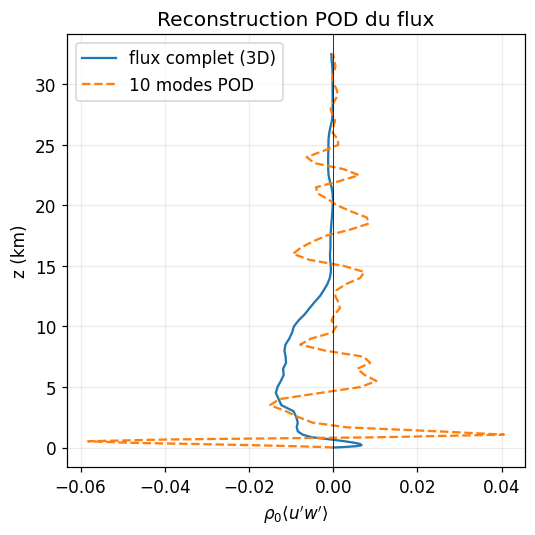

In [13]:

def reconstruct_uw(n1, n2):
    '''u~_N = d(psi_N)/dz / rho0,  w~_N = -d(psi_N)/dx / rho0, pour les modes n1..n2.'''
    psi_N = fmean[None, :, :] + np.einsum('tn,nzx->tzx', a_n[:, n1:n2 + 1], modes[n1:n2 + 1])
    u_N = np.gradient(psi_N, alt, axis=1) / rho0[None, :, None]
    w_N = -np.gradient(psi_N, x, axis=2) / rho0[None, :, None]
    return psi_N, u_N, w_N


psi_N, u_N, w_N = reconstruct_uw(0, n_modes - 1)

up_N = u_N - u_N.mean(axis=(0, 2), keepdims=True)
wp_N = w_N - w_N.mean(axis=(0, 2), keepdims=True)
flux_N_profile = np.mean(up_N * wp_N, axis=(0, 2)) * rho0

# comparaison au flux complet (3D, meme sous-echantillon temporel)
flux_true_profile = flux[:, t_idx_pod].mean(axis=1)
nse_recon = nse(flux_true_profile, flux_N_profile)
print(f'NSE reconstruction flux (via {n_modes} modes POD) = {nse_recon:.3f}')
print('(rappel : psi est moyenne-y, donc cette reconstruction ne capture que la')
print(' partie organisee T1 — coherent avec le residu T2 deja identifie ailleurs.)')

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(flux_true_profile, alt / 1000, label='flux complet (3D)')
ax.plot(flux_N_profile, alt / 1000, '--', label=f'{n_modes} modes POD')
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r"$\rho_0\langle u'w'\rangle$"); ax.set_ylabel('z (km)')
ax.legend(); ax.set_title('Reconstruction POD du flux')
fig.tight_layout(); plt.show()
